<a href="https://colab.research.google.com/github/D1dix/proyecto_IAs/blob/main/03-Seaborn%26Matplotlib/TechStore.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Seaborn: TechStore
# Análisis comercial de ventas tecnológicas
# Generado: 2/3/2026
# === DATASET ===
import pandas as pd
import numpy as np
import matplotlib
#matplotlib.use('Agg')
matplotlib.use('inline')  # o simplemente añade en una celda aparte:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(2024)
n = 2400

meses = np.repeat(['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic'], 200)
region = np.tile(np.repeat(['Madrid', 'Barcelona', 'Valencia', 'Sevilla', 'Bilbao'], 40), 12)
categoria = np.random.choice(['Portatiles', 'Smartphones', 'Tablets', 'Audio', 'Accesorios'], n, p=[0.20, 0.25, 0.15, 0.15, 0.25])

# Precio base por categoria
precio_map = {'Portatiles': 800, 'Smartphones': 500, 'Tablets': 350, 'Audio': 120, 'Accesorios': 45}
precio = np.array([precio_map[c] + np.random.normal(0, precio_map[c]*0.3) for c in categoria])
precio = np.clip(precio, 15, 2000).round(2)

# Unidades vendidas (inversamente proporcional al precio)
unidades = np.array([max(1, int(np.random.exponential(500/precio_map[c]) * 3)) for c in categoria])

# Satisfaccion del cliente
satisfaccion = np.random.normal(4.0, 0.7, n)
satisfaccion = np.clip(satisfaccion, 1, 5).round(1)

# Descuento (mayor en Accesorios, menor en Portatiles)
desc_map = {'Portatiles': 5, 'Smartphones': 8, 'Tablets': 10, 'Audio': 12, 'Accesorios': 15}
descuento = np.array([desc_map[c] + np.random.normal(0, 3) for c in categoria])
descuento = np.clip(descuento, 0, 40).round(1)

# Online vs Tienda fisica
canal_venta = np.random.choice(['Online', 'Tienda'], n, p=[0.45, 0.55])

df = pd.DataFrame({
    'mes': meses,
    'region': region,
    'categoria': categoria,
    'precio': precio,
    'unidades': unidades,
    'satisfaccion': satisfaccion,
    'descuento': descuento,
    'canal_venta': canal_venta
})

# Calcular ingreso total
df['ingreso'] = (df['precio'] * df['unidades'] * (1 - df['descuento']/100)).round(2)

# Orden de meses
orden_meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
df['mes'] = pd.Categorical(df['mes'], categories=orden_meses, ordered=True)

print("Dataset TechStore cargado correctamente")
print(f"Forma: {df.shape}")
print(df.head())

Dataset TechStore cargado correctamente
Forma: (2400, 9)
   mes  region    categoria   precio  unidades  satisfaccion  descuento  \
0  Ene  Madrid      Tablets   425.73         4           4.3       16.0   
1  Ene  Madrid        Audio   141.79        17           3.4       14.1   
2  Ene  Madrid   Portatiles   528.93         1           4.4        3.4   
3  Ene  Madrid   Portatiles  1012.31         1           4.7        5.0   
4  Ene  Madrid  Smartphones   453.67         4           4.0       14.6   

  canal_venta  ingreso  
0      Tienda  1430.45  
1      Tienda  2070.56  
2      Tienda   510.95  
3      Online   961.69  
4      Online  1549.74  


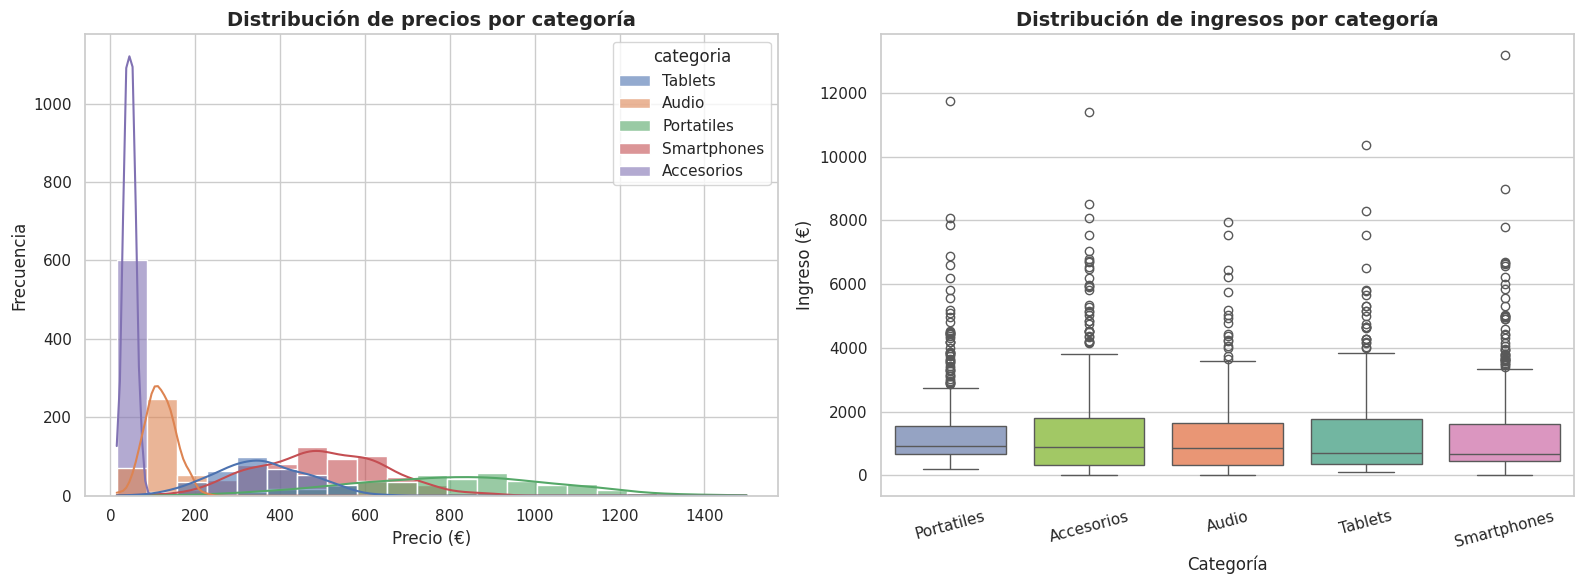

In [ ]:
# EJERCICIO 1: Distribución de ventas por producto

# Aplicar tema limpio de Seaborn
sns.set_theme(style='whitegrid')

# Crear figura con 2 subplots en una fila
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Subplot 1: Histograma de precios ---
sns.histplot(data=df, x='precio', hue='categoria', kde=True, alpha=0.6, ax=axes[0])

axes[0].set_title('Distribución de precios por categoría',
                   fontsize=14, fontweight='bold')
axes[0].set_xlabel('Precio (€)')
axes[0].set_ylabel('Frecuencia')

# --- Subplot 2: Boxplot de ingresos ---
orden = df.groupby('categoria')['ingreso'].median().sort_values(ascending=False).index

sns.boxplot(data=df, x='categoria', y='ingreso', order=orden,
            hue='categoria', palette='Set2', legend=False, ax=axes[1])

axes[1].set_title('Distribución de ingresos por categoría',
                   fontsize=14, fontweight='bold')
axes[1].set_xlabel('Categoría')
axes[1].set_ylabel('Ingreso (€)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

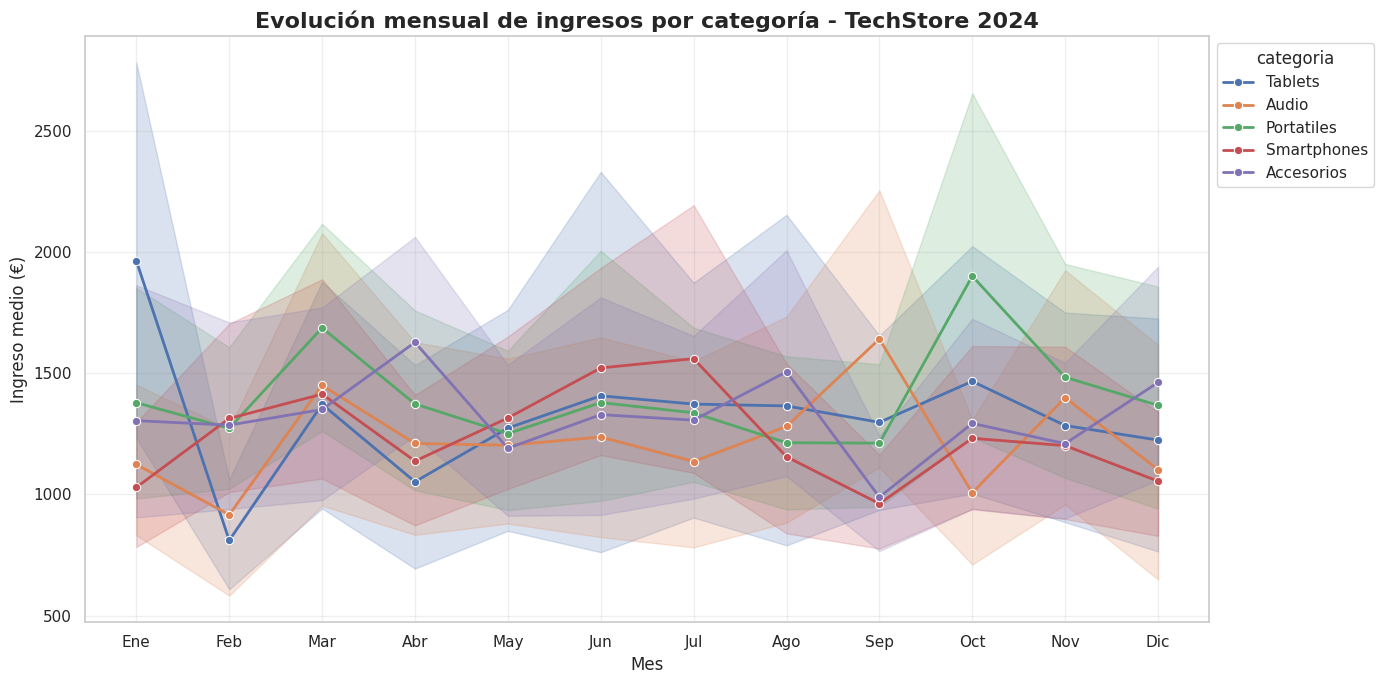

In [ ]:
# EJERCICIO 2: Tendencias temporales
# Dataset disponible: df (2.400 registros con mes categórico ordenado)

# TODO: Crear figura grande

fig, ax = plt.subplots(figsize=(14, 7))


# TODO: Crear lineplot con Seaborn
sns.lineplot(data=df, x='mes', y='ingreso', hue='categoria',
             errorbar=('ci', 95), marker='o', linewidth=2, ax=ax)


# Personalización

# TODO: Mover la leyenda fuera del gráfico
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))


# Personalización
ax.set_title('Evolución mensual de ingresos por categoría - TechStore 2024',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Mes', fontsize=12)
ax.set_ylabel('Ingreso medio (€)', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


/tmp/ipython-input-780/2305359890.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='region', y='ingreso',


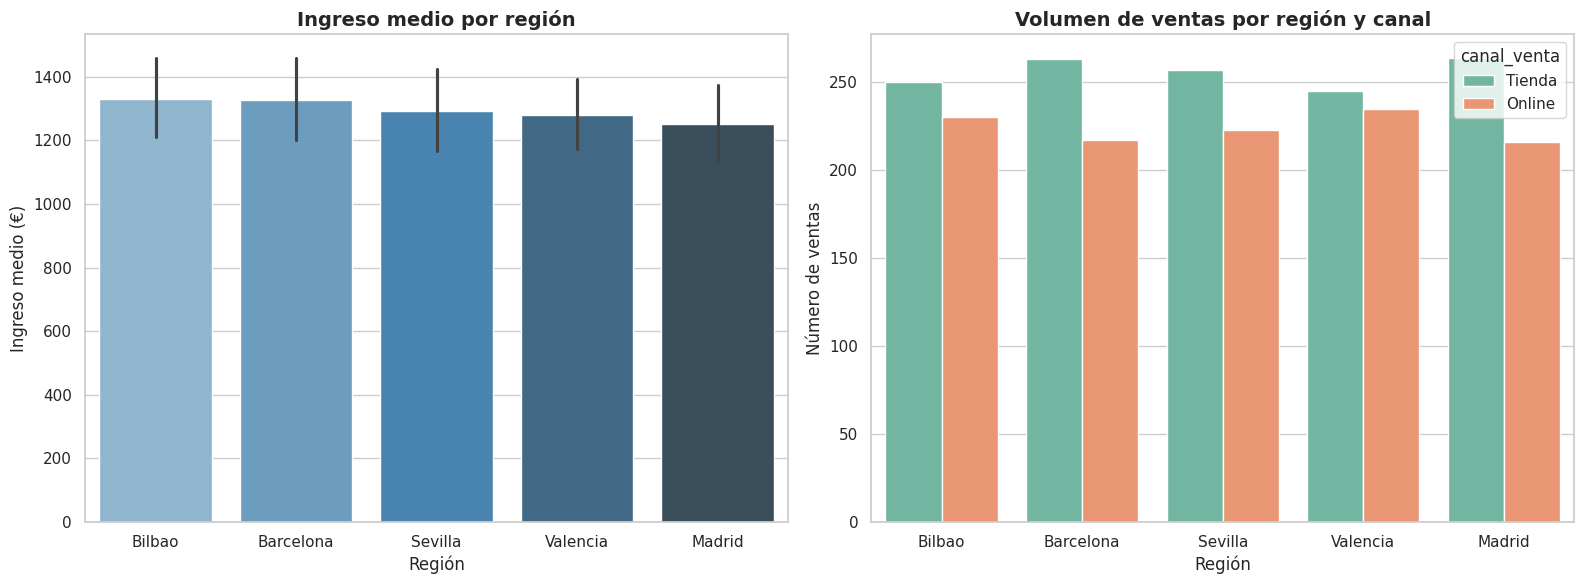

In [ ]:
# EJERCICIO 3: Comparativa por región
# Dataset disponible: df (con columnas region, ingreso, canal_venta)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Calcular orden de regiones por ingreso medio descendente
orden_region = df.groupby('region')['ingreso'].mean().sort_values(ascending=False).index

# --- Subplot 1: Barplot de ingreso medio ---
sns.barplot(data=df, x='region', y='ingreso',
            order=orden_region, palette='Blues_d',
            errorbar='ci', ax=axes[0])
axes[0].set_title('Ingreso medio por región',
                   fontsize=14, fontweight='bold')
axes[0].set_xlabel('Región')
axes[0].set_ylabel('Ingreso medio (€)')


# --- Subplot 2: Countplot por canal de venta ---

sns.countplot(data=df, x='region', hue='canal_venta',
              order=orden_region, palette='Set2', ax=axes[1])

axes[1].set_title('Volumen de ventas por región y canal',
                   fontsize=14, fontweight='bold')
axes[1].set_xlabel('Región')
axes[1].set_ylabel('Número de ventas')

plt.tight_layout()
plt.show()

/tmp/ipython-input-780/3313358795.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='categoria', y='precio',


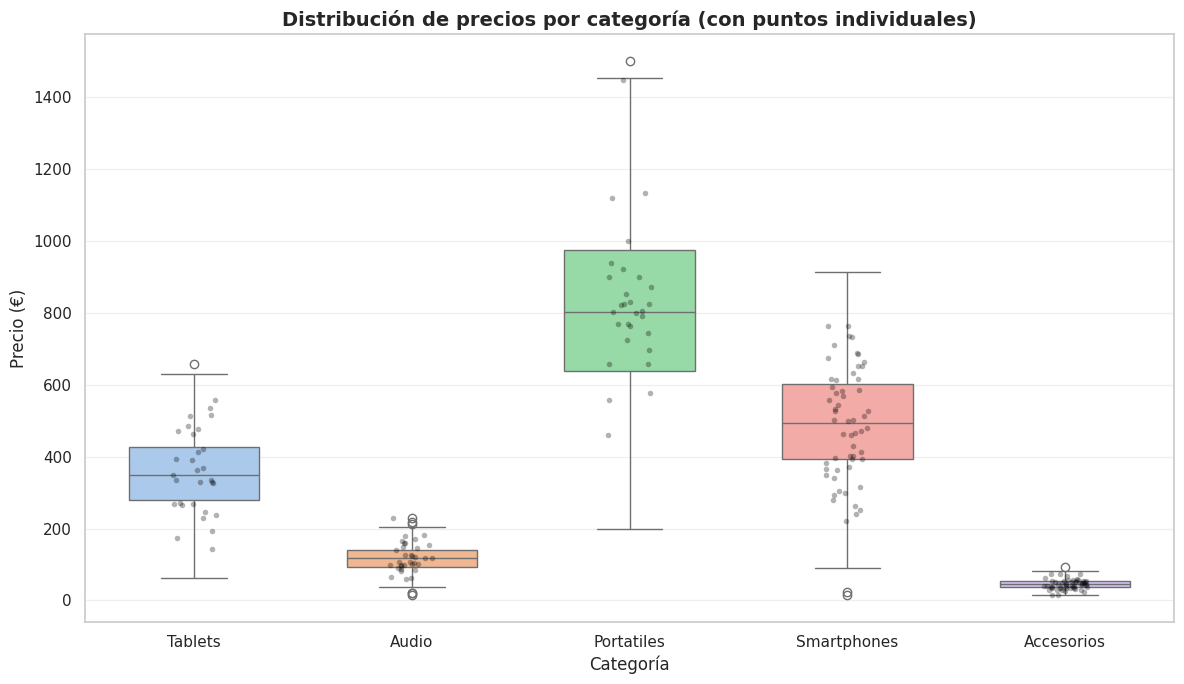

In [ ]:
# EJERCICIO 4: Outliers y dispersión
# Dataset disponible: df (2.400 registros)
# Nota: Si swarmplot es lento, usa stripplot o una muestra con df.sample()

fig, ax = plt.subplots(figsize=(12, 7))

# TODO: Dibujar boxplot de precio por categoría
sns.boxplot(data=df, x='categoria', y='precio',
            palette='pastel', width=0.6, ax=ax)

# TODO: Crear una muestra de 200 registros para rendimiento

muestra = df.sample(200, random_state=42)

# TODO: Superponer stripplot con la muestra
sns.stripplot(data=muestra, x='categoria', y='precio',
              color='black', alpha=0.3, size=4,
              jitter=True, ax=ax)

# Personalización
ax.set_title('Distribución de precios por categoría (con puntos individuales)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Categoría', fontsize=12)
ax.set_ylabel('Precio (€)', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


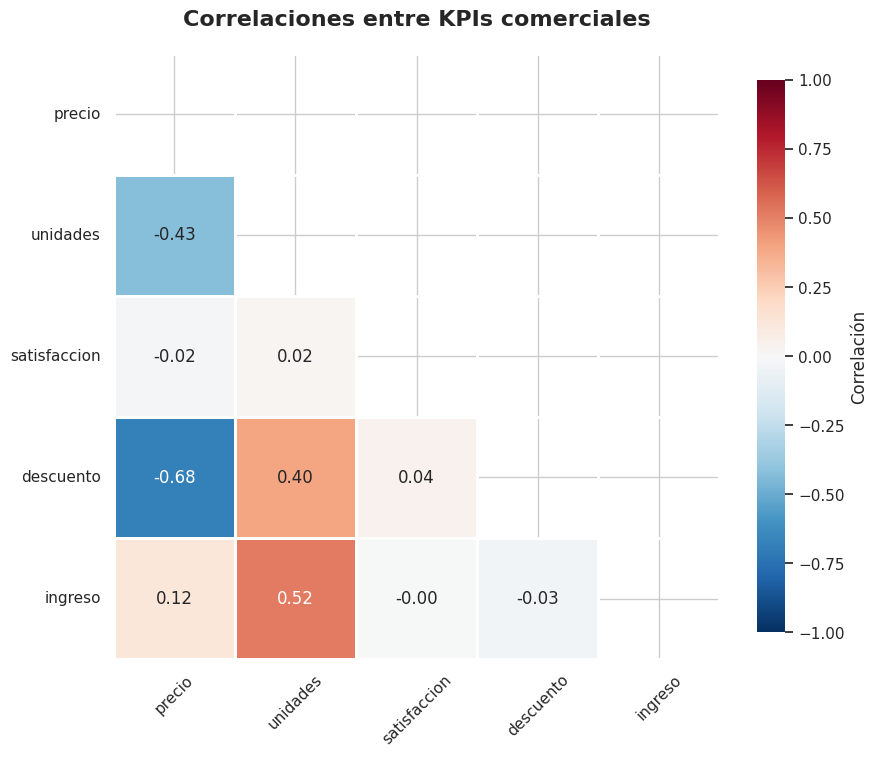

In [ ]:
# EJERCICIO 5: Correlaciones de KPIs
# Dataset disponible: df (columnas numéricas: precio, unidades, satisfaccion, descuento, ingreso)

# Seleccionar columnas numéricas
cols_num = ['precio', 'unidades', 'satisfaccion', 'descuento', 'ingreso']

# TODO: Calcular la matriz de correlación
corr = df[cols_num].corr()

# TODO: Crear máscara triangular superior
mask = np.triu(np.ones_like(corr, dtype=bool))


# TODO: Dibujar heatmap con Seaborn
fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=1,
            cbar_kws={'shrink': 0.8, 'label': 'Correlación'},
            ax=ax)


ax.set_title('Correlaciones entre KPIs comerciales',
             fontsize=16, fontweight='bold', pad=20)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()


/tmp/ipython-input-780/152571479.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, y='categoria', x='ingreso',


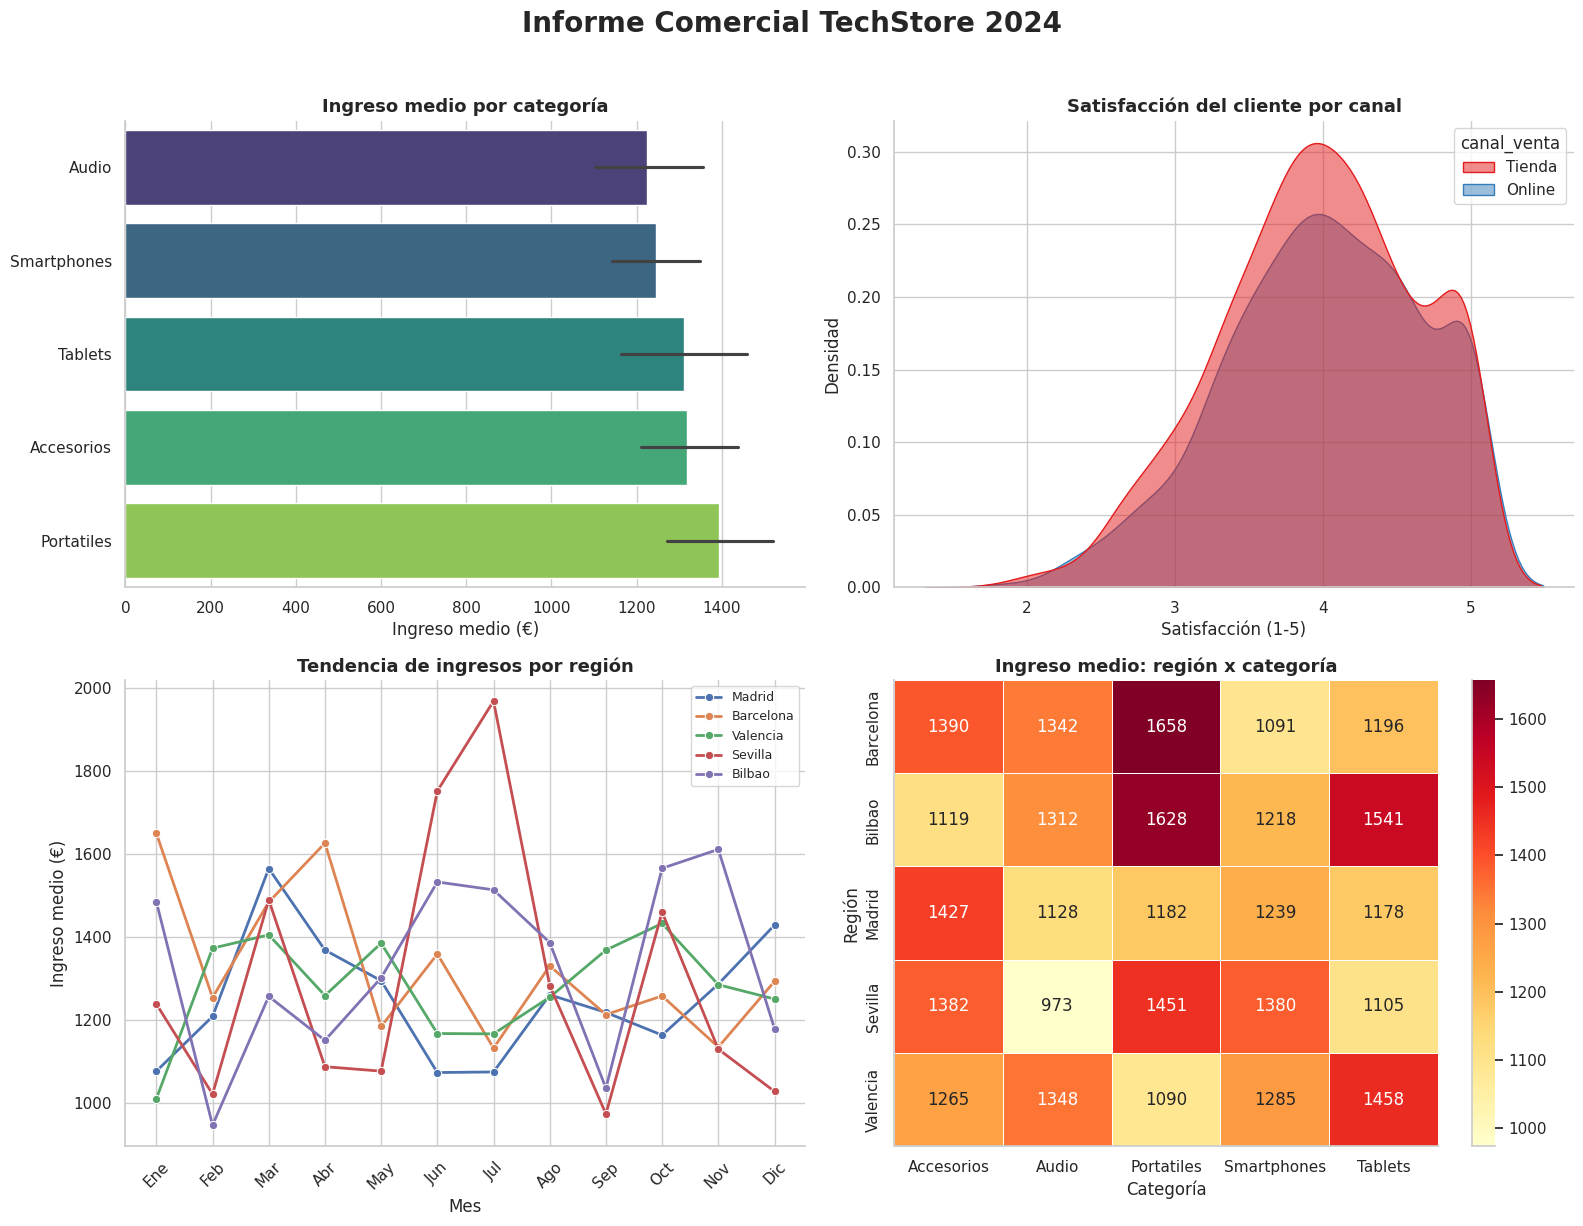

In [ ]:
# EJERCICIO 6: Informe visual completo - Dashboard 2x2
# Dataset disponible: df (completo con todas las columnas)

sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# === [0,0] Barplot horizontal: Ingreso medio por categoría ===
orden_cat = df.groupby('categoria')['ingreso'].mean().sort_values().index
sns.barplot(data=df, y='categoria', x='ingreso',
            order=orden_cat, palette='viridis', errorbar='ci', ax=axes[0, 0])

axes[0, 0].set_title('Ingreso medio por categoría', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Ingreso medio (€)')
axes[0, 0].set_ylabel('')

# === [0,1] KDE: Satisfacción por canal de venta ===

sns.kdeplot(data=df, x='satisfaccion', hue='canal_venta',
            fill=True, alpha=0.5, palette='Set1', ax=axes[0, 1])
axes[0, 1].set_title('Satisfacción del cliente por canal', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Satisfacción (1-5)')
axes[0, 1].set_ylabel('Densidad')

# === [1,0] Lineplot: Tendencia mensual por región ===
sns.lineplot(data=df, x='mes', y='ingreso', hue='region',
            errorbar=None, marker='o', linewidth=2, ax=axes[1, 0])

axes[1, 0].set_title('Tendencia de ingresos por región', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Mes')
axes[1, 0].set_ylabel('Ingreso medio (€)')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].legend(fontsize=9)

# === [1,1] Heatmap: Pivot región x categoría ===

sns.heatmap(df.pivot_table(values='ingreso', index='region', columns='categoria', aggfunc='mean'), annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5, ax=axes[1, 1])

axes[1, 1].set_title('Ingreso medio: región x categoría', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Categoría')
axes[1, 1].set_ylabel('Región')

# Limpieza profesional
sns.despine()
fig.suptitle('Informe Comercial TechStore 2024',
             fontsize=20, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()


========== ANALISIS UNIVARIABLE ==========

Resumen estadístico:


,precio,unidades,satisfaccion,descuento,ingreso
count,2400.00,2400.00,2400.00,2400.00,2400.00
mean,358.68,12.14,3.99,10.11,1296.68
std,304.96,22.27,0.66,4.66,1354.10
min,15.00,1.00,1.80,0.00,17.63
25%,66.56,1.00,3.50,6.60,440.19
50%,315.24,3.00,4.00,10.10,835.21
75%,553.63,12.00,4.50,13.50,1679.17
max,1499.71,201.00,5.00,23.50,13174.36



Frecuencia de categoria:


,count
categoria,
Smartphones,633
Accesorios,602
Portatiles,434
Audio,374
Tablets,357



Frecuencia de region:


,count
region,
Madrid,480
Barcelona,480
Valencia,480
Sevilla,480
Bilbao,480



Frecuencia de canal_venta:


,count
canal_venta,
Tienda,1279
Online,1121


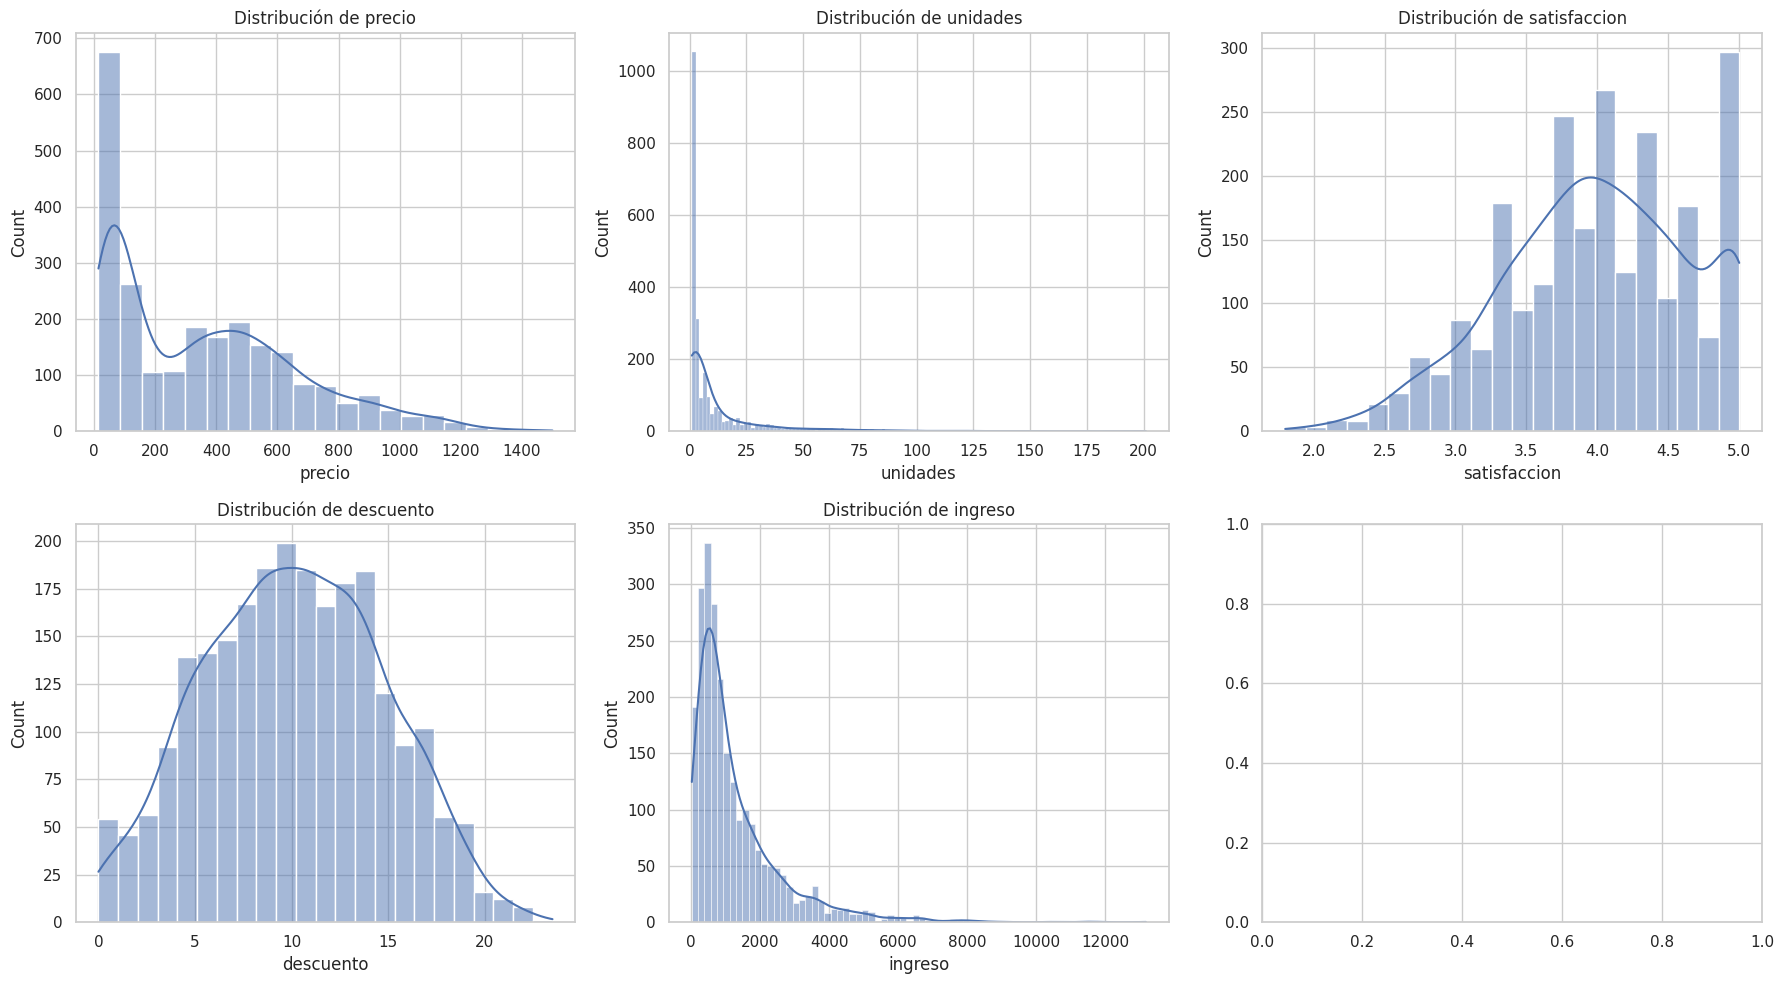


========== ANALISIS BIVARIABLE ==========



,precio,unidades,satisfaccion,descuento,ingreso
precio,1.00,-0.43,-0.02,-0.68,0.12
unidades,-0.43,1.00,0.02,0.40,0.52
satisfaccion,-0.02,0.02,1.00,0.04,-0.00
descuento,-0.68,0.40,0.04,1.00,-0.03
ingreso,0.12,0.52,-0.00,-0.03,1.00


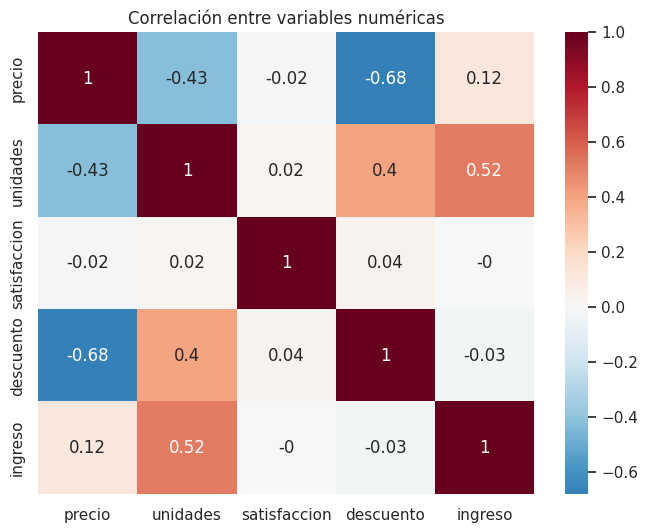

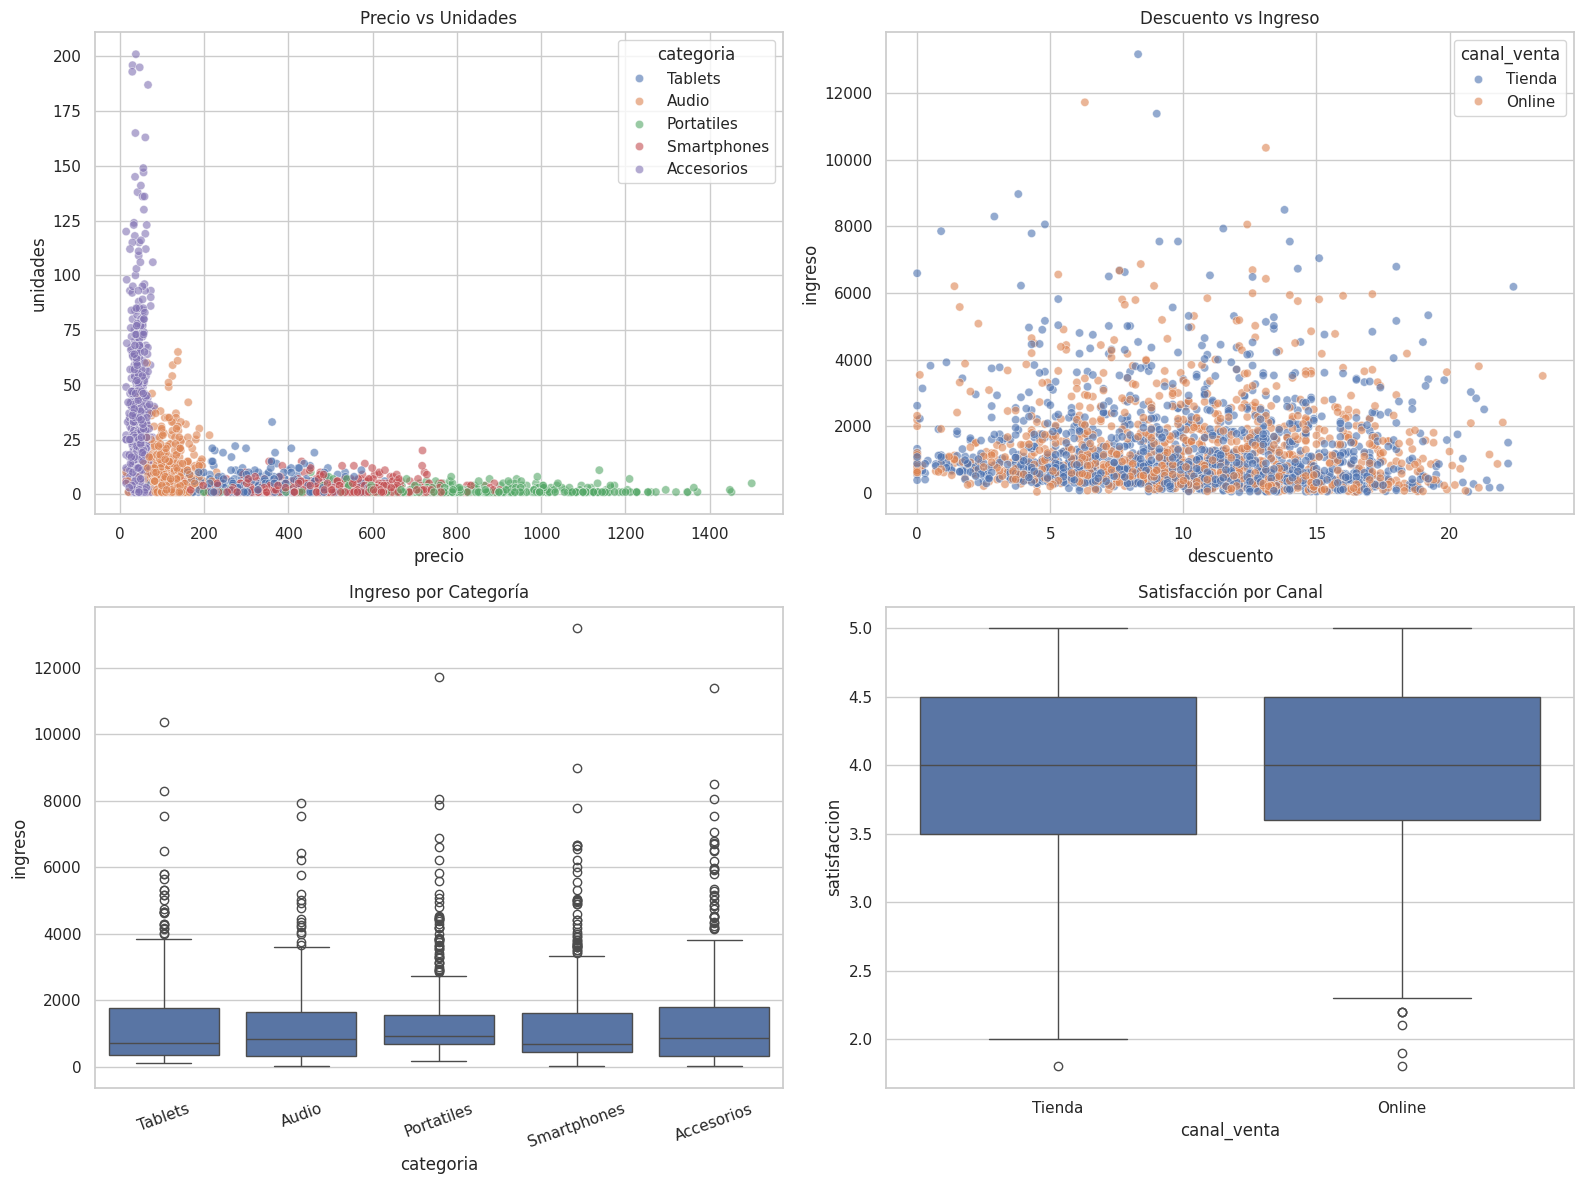


 CONCLUSIONES AUTOMÁTICAS 

✔ Precio medio: 358.68 €
✔ Ingreso medio: 1296.68 €
✔ Satisfacción media: 3.99/5

Categoría con mayor ingreso medio:
Portatiles

Región con mayor ingreso medio:
Bilbao

Correlación más fuerte con ingreso:
0.52


/tmp/ipython-input-780/2775492486.py:88: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(corr['ingreso'].sort_values(ascending=False)[1])


In [ ]:
# ANALISIS GLOBAL: UNIVARIABLE + BIVARIABLE (TODO EN UNO)

sns.set_theme(style="whitegrid")

print("\n========== ANALISIS UNIVARIABLE ==========\n")

cols_num = ['precio', 'unidades', 'satisfaccion', 'descuento', 'ingreso']

print("Resumen estadístico:")
display(df[cols_num].describe().round(2))

cols_cat = ['categoria', 'region', 'canal_venta']

for col in cols_cat:
    print(f"\nFrecuencia de {col}:")
    display(df[col].value_counts())


# VISUALIZACION UNIVARIABLE

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, col in enumerate(cols_num):
    sns.histplot(df[col], kde=True, ax=axes.flat[i])
    axes.flat[i].set_title(f'Distribución de {col}')

plt.tight_layout()
plt.show()


# ANALISIS BIVARIABLE

print("\n========== ANALISIS BIVARIABLE ==========\n")

corr = df[cols_num].corr().round(2)
display(corr)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0)
plt.title("Correlación entre variables numéricas")
plt.show()


fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Precio vs Unidades
sns.scatterplot(data=df, x='precio', y='unidades',
                hue='categoria', alpha=0.6, ax=axes[0,0])
axes[0,0].set_title("Precio vs Unidades")

# Descuento vs Ingreso
sns.scatterplot(data=df, x='descuento', y='ingreso',
                hue='canal_venta', alpha=0.6, ax=axes[0,1])
axes[0,1].set_title("Descuento vs Ingreso")

# Categoría vs Ingreso
sns.boxplot(data=df, x='categoria', y='ingreso', ax=axes[1,0])
axes[1,0].tick_params(axis='x', rotation=20)
axes[1,0].set_title("Ingreso por Categoría")

# Canal vs Satisfacción
sns.boxplot(data=df, x='canal_venta', y='satisfaccion', ax=axes[1,1])
axes[1,1].set_title("Satisfacción por Canal")

plt.tight_layout()
plt.show()


# CONCLUSIONES
print("\n CONCLUSIONES \n")

print(f"✔ Precio medio: {df['precio'].mean():.2f} €")
print(f"✔ Ingreso medio: {df['ingreso'].mean():.2f} €")
print(f"✔ Satisfacción media: {df['satisfaccion'].mean():.2f}/5")

print("\nCategoría con mayor ingreso medio:")
print(df.groupby('categoria')['ingreso'].mean().idxmax())

print("\nRegión con mayor ingreso medio:")
print(df.groupby('region')['ingreso'].mean().idxmax())

print("\nCorrelación más fuerte con ingreso:")
print(corr['ingreso'].sort_values(ascending=False)[1])